# **SymptoScan**

### 🐾 AI-based animal disease prediction system that analyzes animal health information and symptoms to support early disease screening.

## 1. Loading the datasets

In this part, we load the original animal disease dataset from Kaggle and also load the generated dataset that we will use later for comparison.

At this stage, we will not combine or change the datasets yet. We just want to check their sizes and understand how much data we have in each one.

The original dataset will be treated as the real data, while the generated dataset will be used separately to investigate whether adding synthetic data changes the model performance.

In [117]:
import warnings
import numpy as np #numpy
import pandas as pd #pandas
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset/animal_disease_prediction.csv")
df_generated = pd.read_csv("Dataset/generated_dataset.csv")
pd.set_option('display.width', 120)

warnings.filterwarnings('ignore')
print("Original Dataset from Kaggle\n",df.shape)
print("Generated Dataset by AI\n",df_generated.shape)

Original Dataset from Kaggle
 (431, 22)
Generated Dataset by AI
 (10031, 22)


In [118]:
df.info()

# Create a copy 
df_copy = df.copy()
df_generated_copy = df_generated.copy()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    str    
 1   Breed               431 non-null    str    
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    str    
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    str    
 6   Symptom_2           431 non-null    str    
 7   Symptom_3           431 non-null    str    
 8   Symptom_4           431 non-null    str    
 9   Duration            431 non-null    str    
 10  Appetite_Loss       431 non-null    str    
 11  Vomiting            431 non-null    str    
 12  Diarrhea            431 non-null    str    
 13  Coughing            431 non-null    str    
 14  Labored_Breathing   431 non-null    str    
 15  Lameness            431 non-null    str    
 16  Skin_Lesions       

## 2. Data Preprocessing

In this part, we clean and prepare the data before training the models.

First, we check for and remove duplicate rows and remove extra spaces. We also check the data types and convert columns to the correct format.

We remove the Breed column because it has many different categories compared with the size of the real dataset. Keeping it could make the model learn very specific breed patterns instead of learning more general disease patterns.

We also check missing values and make sure the numerical and categorical features are in a suitable format for the models.

After cleaning the data, we check the dataset again to make sure the features and target column are ready for the next steps.

In [119]:
# Remove extra-spaces from the beginning and end of column names
df_copy.columns, df_generated_copy.columns = df_copy.columns.str.strip(), df_generated_copy.columns.str.strip()

In [120]:
# How many Animal type + Breed are there
print(df_copy[['Animal_Type','Breed']].nunique())
print("Animal_Type:",df_copy['Animal_Type'].unique())
print("---------")
print("Breed:",df_copy['Breed'].unique())

Animal_Type      8
Breed          120
dtype: int64
Animal_Type: <ArrowStringArray>
['Dog', 'Cat', 'Cow', 'Horse', 'Rabbit', 'Sheep', 'Goat', 'Pig']
Length: 8, dtype: str
---------
Breed: <ArrowStringArray>
[         'Labrador',           'Siamese',          'Holstein',            'Beagle',           'Persian',
      'Thoroughbred',   'German Shepherd',        'Maine Coon',           'Bulldog',            'Jersey',
 ...
        'Andalusian',             'Tunis',          'Red Poll',          'Pietrain',       'English Lop',
         'Blackface',   'Belted Galloway', 'Yorkshire Terrier',       'Rambouillet',     'Chester White']
Length: 120, dtype: str


In [121]:
# Remove breed from the both datasets
df_copy.drop(columns=['Breed'], inplace=True)
df_generated_copy.drop(columns=['Breed'], inplace=True)
print(df_copy.columns)

Index(['Animal_Type', 'Age', 'Gender', 'Weight', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Duration',
       'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions',
       'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature', 'Heart_Rate', 'Disease_Prediction'],
      dtype='str')


In [122]:
# Check Missing Values
print(df_copy.isnull().sum())

Animal_Type           0
Age                   0
Gender                0
Weight                0
Symptom_1             0
Symptom_2             0
Symptom_3             0
Symptom_4             0
Duration              0
Appetite_Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored_Breathing     0
Lameness              0
Skin_Lesions          0
Nasal_Discharge       0
Eye_Discharge         0
Body_Temperature      0
Heart_Rate            0
Disease_Prediction    0
dtype: int64


In [123]:
df_copy[df_copy.duplicated]

,Animal_Type,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,Appetite_Loss,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
421,Dog,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,Yes,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
422,Cat,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,No,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
423,Cow,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,Yes,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
424,Dog,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,Yes,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
425,Cat,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,Yes,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection
426,Horse,6,Female,500.0,Coughing,Labored Breathing,Nasal Discharge,Fever,10 days,Yes,...,No,Yes,Yes,No,No,Yes,No,39.8°C,85,Equine Influenza
427,Dog,3,Female,30.0,Lameness,Fever,Skin Lesions,Lethargy,7 days,Yes,...,No,No,No,Yes,Yes,No,No,39.3°C,110,Lyme Disease
428,Cat,2,Male,6.0,Vomiting,Appetite Loss,Lethargy,Diarrhea,4 days,Yes,...,Yes,No,No,No,No,No,No,39.1°C,140,Intestinal Parasites
429,Dog,5,Male,23.0,Labored Breathing,Coughing,Nasal Discharge,Appetite Loss,6 days,Yes,...,No,Yes,Yes,No,No,Yes,No,40.0°C,115,Canine Distemper
430,Cow,4,Female,580.0,Lethargy,Decreased Milk Yield,Fever,No,8 days,Yes,...,No,No,No,No,No,No,No,39.6°C,70,Mastitis


In [124]:
# Remove Duplicated Rows
df_copy = df_copy.drop_duplicates()
print(df_copy.shape)

(421, 21)


In [125]:
# Fix features' datatype (Symptoms)
def fix_bool_features(df):
    bool_features = df[['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness',
           'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge']]

    for feature in bool_features:
        df[feature] = df[feature].str.strip().str.lower().map({'yes': True, 'no': False})
        df.head()

    return df

#Change symptoms type on the both datasets
df_copy = fix_bool_features(df_copy)
df_generated_copy = fix_bool_features(df_generated_copy)


**Analysis of the Symptoms**: We analyze the four text-based symptom columns: Symptom_1 to Symptom_4.

We first check the values in each column to understand what kind of symptoms we have and how often they appear.

From this analysis, we found that some symptoms are already available in the existing Boolean columns, while some have different names but the same meaning. We also found some new symptoms that are not included in the existing Boolean columns.

For example, “Loss Of Appetite”, “Reduced Appetite”, and “Appetite Loss” describe the same symptom. We also found similar cases for reduced milk production, reduced wool production, and swelling.

Because of this, we decided to standardize these symptoms instead of keeping the same information in different forms.

In [126]:
# Analysis all the Symptoms columns
# Distribution of Symptoms across Symptom_1 to Symptom_4
print(df_copy['Symptom_1'].value_counts(),"\n")
print(df_copy['Symptom_2'].value_counts(),"\n")
print(df_copy['Symptom_3'].value_counts(),"\n")
print(df_copy['Symptom_4'].value_counts(),"\n")

Symptom_1
Coughing                139
Vomiting                 61
Lameness                 54
Lethargy                 50
Sneezing                 33
Nasal Discharge          23
Fever                    14
Diarrhea                 11
Appetite Loss             8
Swollen Joints            8
Eye Discharge             7
Weight Loss               7
Labored Breathing         2
Loss of Appetite          2
Skin Lesions              1
Decreased Milk Yield      1
Name: count, dtype: int64 

Symptom_2
Loss of Appetite           155
Diarrhea                    43
Nasal Discharge             40
Vomiting                    35
Lethargy                    22
Swollen Legs                21
Coughing                    20
Fever                       18
Labored Breathing           12
Appetite Loss               11
Swollen Joints              11
Eye Discharge                9
Dehydration                  6
Sneezing                     5
Weight Loss                  4
Lameness                     3
Decrease

The idea here is to convert the text symptoms into the existing Boolean symptom features so that all symptoms have a consistent format.

First, we clean the text by removing extra spaces and converting everything to lowercase. Then, we create a mapping for symptoms that have different names but the same meaning.

For each row, we check **Symptom_1 to Symptom_4** and mark the corresponding Boolean feature as `True` if the symptom is found. For example, **“Loss of Appetite”, “Reduced Appetite”, and “Appetite Loss”** are all mapped to `Appetite_Loss`.

We also add the new symptoms that we found, such as **Fever, Lethargy, Sneezing, Weight Loss, and Dehydration**.

After mapping the symptoms, we remove the original `Symptom_1` to `Symptom_4` columns because their information has already been converted into the standardized Boolean features. This gives us a cleaner and more consistent set of symptom features for the models.


In [127]:
# Mapping ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4'] into the bool features
# Assign all the Symptoms into bool features
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4']

def standardize_symptoms(df):
    # 1. Clean raw text columns
    for col in symptom_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # 2. Synonym map
    synonym_map = {
        'Appetite_Loss': ['appetite loss', 'loss of appetite', 'reduced appetite', 'decreased appetite'],
        'Reduced_Milk': ['reduced milk production', 'decreased milk yield'],
        'Reduced_Wool': ['reduced wool production', 'reduced wool growth'],
        'Swelling': ['swollen joints', 'swollen legs', 'swelling', 'reduced mobility'],
        'Fever': ['fever'],
        'Lethargy': ['lethargy'],
        'Weight_Loss': ['weight loss'],
        'Dehydration': ['dehydration'],
        'Sneezing': ['sneezing']
    }

    # 3. Create normalized binary symptom columns
    for std_name, variations in synonym_map.items():
        # Check if any variation appears across Symptom_1 to Symptom_4 for each row
        df[std_name] = df[symptom_cols].apply(lambda row: row.isin(variations).any(), axis=1).astype(bool)

    # 4. Drop original symptom columns after normalization
    df.drop(columns=symptom_cols, inplace=True)

    return df

df_copy = standardize_symptoms(df_copy)
df_generated_copy = standardize_symptoms(df_generated_copy)

print(df_copy.columns)

Index(['Animal_Type', 'Age', 'Gender', 'Weight', 'Duration', 'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing',
       'Labored_Breathing', 'Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature',
       'Heart_Rate', 'Disease_Prediction', 'Reduced_Milk', 'Reduced_Wool', 'Swelling', 'Fever', 'Lethargy',
       'Weight_Loss', 'Dehydration', 'Sneezing'],
      dtype='str')


In [128]:
# Clean Body Temperature values and convert to float
def clean_body_temperature(df):
    df['Body_Temperature'] = (
        df['Body_Temperature']
        .astype(str)
        .str.replace('°C', '', regex=False)
        .str.strip()
        .astype(float)
    )
    return df

df_copy = clean_body_temperature(df_copy)
df_generated_copy = clean_body_temperature(df_generated_copy)

df_copy[['Body_Temperature']]


,Body_Temperature
0,39.5
1,38.9
2,40.1
3,39.2
4,38.7
...,...
416,39.2
417,39.2
418,39.1
419,39.4


In [129]:
#Convert Duration text into numeric days
def duration_to_days(value):
    value = str(value).lower().strip()
    num = int(''.join(filter(str.isdigit, value)))
    if 'week' in value:
        return num * 7
    elif 'month' in value:
        return num * 30
    else:  # days
        return num

# Drop Duration column after creating Duration_Days
def clean_duration(df):
    df['Duration_Days'] = df['Duration'].apply(duration_to_days)
    df.drop(columns=['Duration'], inplace=True)
    return df

df_copy = clean_duration(df_copy)
df_generated_copy = clean_duration(df_generated_copy)

## 3. Data Visualization

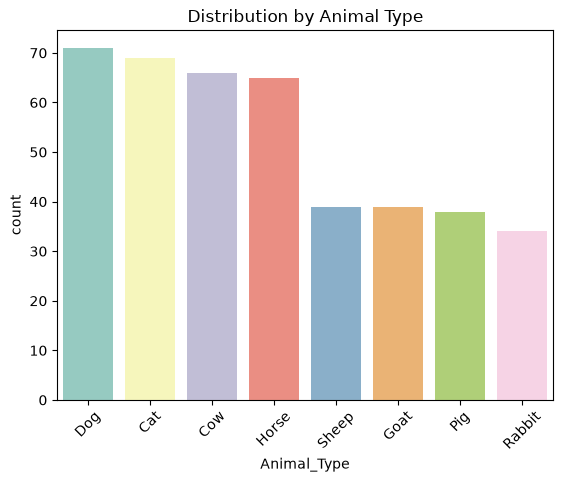

In [130]:
# The Expected Animal Types
sns.countplot(
    data=df_copy,
    x='Animal_Type',
    order=df_copy['Animal_Type'].value_counts().index ,palette='Set3')
plt.title("Distribution by Animal Type")
plt.xticks(rotation=45)
plt.savefig('Visualization-image/animal_type_distribution.png', dpi=300)
plt.show()

**Animal Type Distribution**

This plot shows the distribution of animal types in the original dataset. Dogs and cats have the highest number of records, while rabbits have the lowest. The distribution is not completely balanced, so we consider this when evaluating the models.

Number of unique diseases: 139


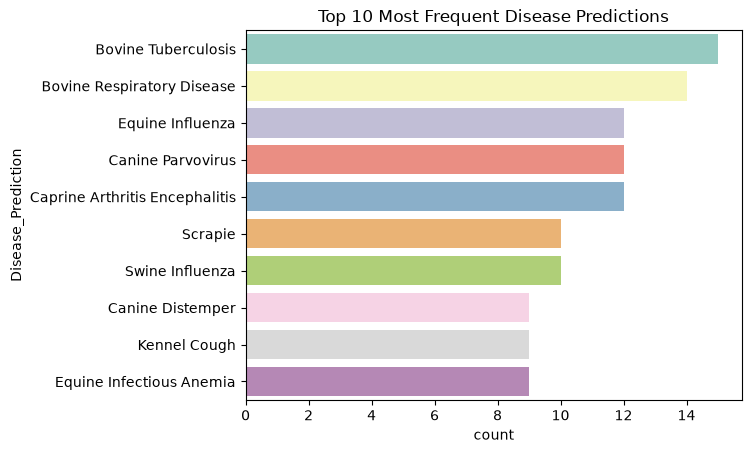

In [131]:
print("Number of unique diseases:", df_copy['Disease_Prediction'].nunique())
sns.countplot(
    data=df_copy,
    y ='Disease_Prediction',
    order=df_copy['Disease_Prediction'].value_counts().head(10).index,palette='Set3')

plt.title("Top 10 Most Frequent Disease Predictions")
plt.savefig('Visualization-image/most_frequent_disease.png', dpi=300)
plt.show()

The dataset contains **139 different disease classes**. The top 10 diseases have different numbers of records, showing that the classes are not perfectly balanced. This is important because diseases with fewer records may be harder for the models to learn and predict correctly.


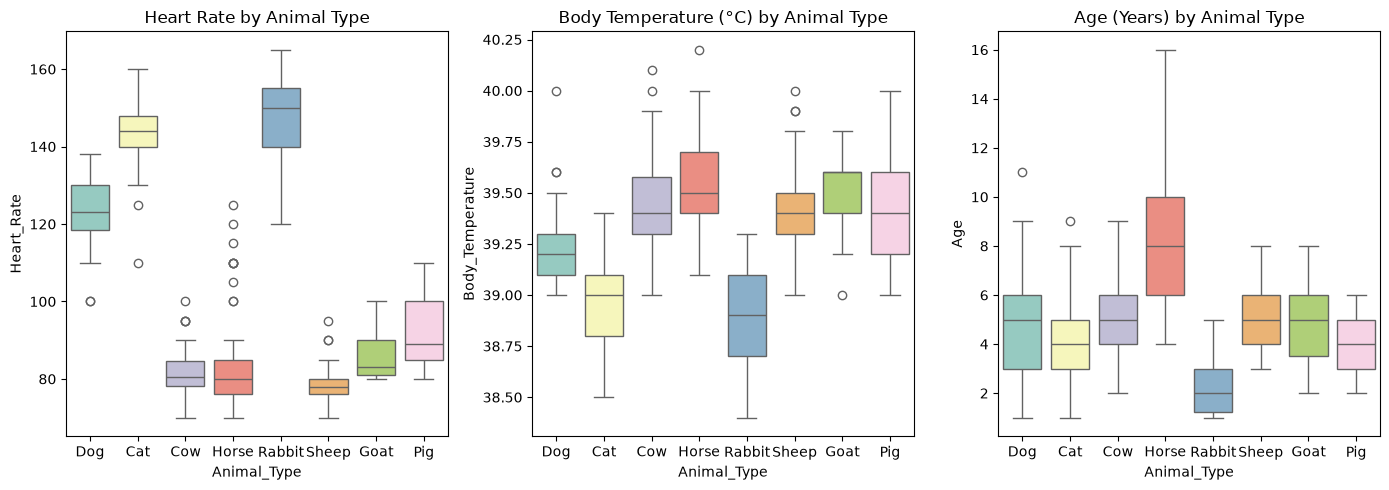

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
sns.boxplot(data=df_copy, x='Animal_Type', y='Heart_Rate', palette='Set3', ax=axes[0])
axes[0].set_title('Heart Rate by Animal Type')

sns.boxplot(data=df_copy, x='Animal_Type', y='Body_Temperature', palette='Set3', ax=axes[1])
axes[1].set_title('Body Temperature (°C) by Animal Type')

sns.boxplot(data=df_copy, x='Animal_Type', y='Age', palette='Set3', ax=axes[2])
axes[2].set_title('Age (Years) by Animal Type')

plt.tight_layout()
plt.savefig('Visualization-image/vitals_distribution.png', dpi=300)
plt.show()

The boxplots show differences in heart rate, body temperature, and age across animal types. Some outliers are visible, especially in heart rate. These values were kept because they may represent genuine clinical cases rather than data-entry errors. Removing them could remove useful information about animals with unusual health conditions.

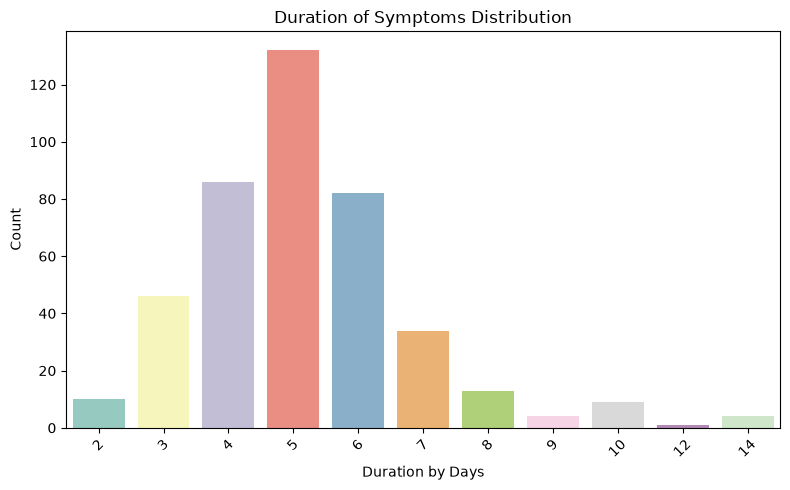

In [133]:
# Symptom Duration Distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_copy,
    x='Duration_Days',
    palette='Set3',
    order=df_copy['Duration_Days'].value_counts().sort_index().index
)
plt.title('Duration of Symptoms Distribution')
plt.xlabel('Duration by Days')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('Visualization-image/duration_of_symptoms_distribution.png', dpi=300)
plt.tight_layout()
plt.show()

The symptom duration varies across the records, with some durations occurring more frequently than others. This feature provides information about how long the animal has experienced symptoms and may help the model distinguish between different disease patterns.

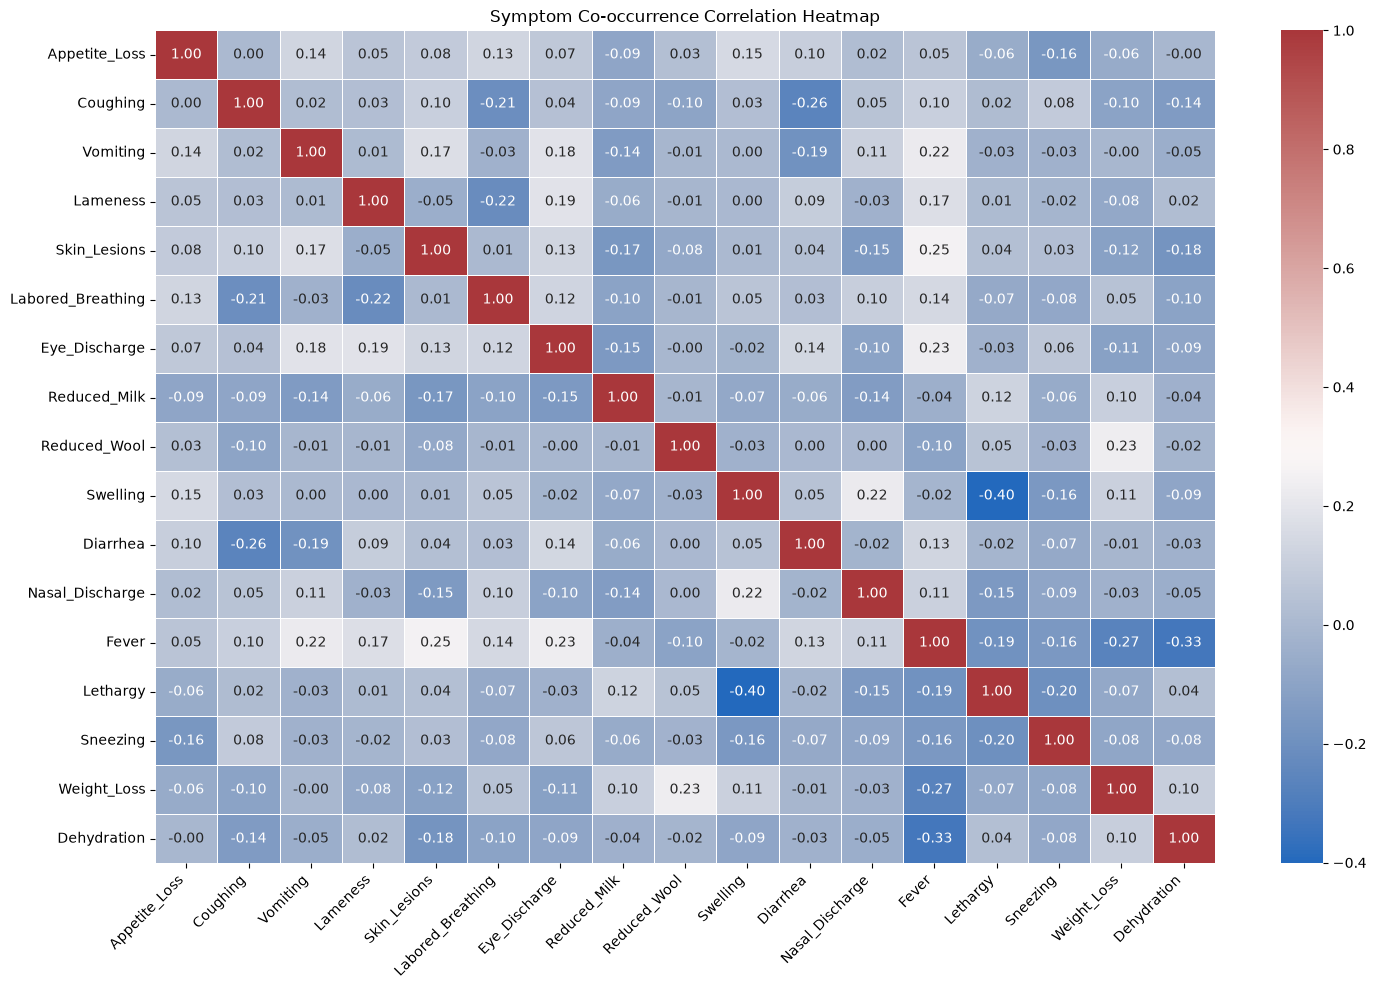

In [134]:
# Symptom Co-occurrence Correlation Heatmap
symptom_cols = ['Appetite_Loss', 'Coughing', 'Vomiting', 'Lameness',
                'Skin_Lesions', 'Labored_Breathing', 'Eye_Discharge','Reduced_Milk','Reduced_Wool','Swelling',
                'Diarrhea', 'Nasal_Discharge','Fever','Lethargy', 'Sneezing','Weight_Loss', 'Dehydration']
symptom_df = (df_copy[symptom_cols] == True).astype(int)
corr_matrix = symptom_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', linewidths=0.5)
plt.title('Symptom Co-occurrence Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.savefig('Visualization-image/symptoms_heatmap.png', dpi=300)
plt.tight_layout()
plt.show()

The heatmap shows the correlation between different symptoms. Some symptoms have stronger positive correlations, meaning they tend to appear together in the same records. Other symptoms have weak or near-zero correlations, suggesting they occur more independently. This helps us understand relationships between symptoms before training the classification models.

## 4. Feature Engineering

In this part, we prepare the cleaned data so it can be used for machine learning models.

First, we create a copy of the cleaned dataset so that we can make changes without affecting the previous version. We also separate the features into three groups: **symptoms, categorical features, and numerical features**.

The symptom columns are converted from Boolean values (`True`/`False`) into numerical values (`1`/`0`). This makes them easier for the machine learning models to use. Missing symptom values are also treated as `False`, meaning that the symptom is not recorded for that patient.

The categorical features are **Animal_Type** and **Gender**, while the numerical features include **Age, Weight, Heart_Rate, Body_Temperature, and Duration_Days**.

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df_fe = df_copy.copy()

symptoms = ['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing','Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge','Reduced_Milk', 'Reduced_Wool', 'Swelling', 'Fever', 'Lethargy',
'Weight_Loss', 'Dehydration', 'Sneezing']

#Converted the symptoms into numeric
df_fe[symptoms] = df_fe[symptoms].fillna(False).astype(int)
print("dtypes:", df_fe[symptoms].dtypes.unique())

cat_features = ["Animal_Type","Gender"]
num_features = ['Age', 'Weight', 'Heart_Rate', 'Body_Temperature', 'Duration_Days']

dtypes: [dtype('int64')]


Next, we check the number of records for each disease. This is important because the dataset contains many different disease classes, but some diseases have only a few records. We check the number of diseases, the number of records per disease, and especially the diseases that have only one record.

In [136]:
# Check the number of records for each disease
disease_counts = df_fe["Disease_Prediction"].value_counts()

print("\nDisease counts:", disease_counts)
print("\nDiseases with only 1 record:", disease_counts[disease_counts == 1])
print("\nNumber of diseases with only 1 record:",(disease_counts == 1).sum())


Disease counts: Disease_Prediction
Bovine Tuberculosis                15
Bovine Respiratory Disease         14
Equine Influenza                   12
Canine Parvovirus                  12
Caprine Arthritis Encephalitis     12
                                   ..
Goat Pox                            1
Porcine Epidemic Diarrhea Virus     1
Canine Infectious Hepatitis         1
Feline Panleukopenia Virus          1
Porcine Circovirus Disease          1
Name: count, Length: 139, dtype: int64

Diseases with only 1 record: Disease_Prediction
Fungal Infection                                 1
Lyme Disease                                     1
Intestinal Parasites                             1
Strangles                                        1
Tick-Borne Disease                               1
Arthritis                                        1
Heartworm Disease                                1
Equine Viral Arteritis                           1
Conjunctivitis                                   1

In [137]:
print("\nDisease classes:", df_fe["Disease_Prediction"].nunique())
print("\nNumber of diseases by record count:")
print(disease_counts.value_counts().sort_index())


Disease classes: 139

Number of diseases by record count:
count
1     60
2     27
3     15
4      9
5      6
6      4
7      4
8      4
9      3
10     2
12     3
14     1
15     1
Name: count, dtype: int64


We also check the disease names to find labels that may refer to the same disease but are written differently. For example, we found different versions of **Bluetongue**, so we inspected these labels before deciding how to standardize them.

In [138]:
# Sort disease, check similarity
disease_names = sorted(df_fe["Disease_Prediction"].unique())
for disease in disease_names:
    print(disease)

Actinobacillus Pleuropneumonia
Actinobacillus Suis
African Swine Fever
Allergic Rhinitis
Arthritis
Blue Tongue
Blue Tongue Disease
Blue Tongue Virus
Bluetongue
Bluetongue Virus
Bordetella Infection
Bovine Coccidiosis
Bovine Influenza
Bovine Johne's Disease
Bovine Leukemia Virus
Bovine Mastitis
Bovine Parainfluenza
Bovine Pneumonia
Bovine Respiratory Disease
Bovine Respiratory Disease Complex
Bovine Respiratory Syncytial Virus
Bovine Tuberculosis
Bovine Viral Diarrhea
Canine Cough
Canine Distemper
Canine Flu
Canine Heartworm Disease
Canine Hepatitis
Canine Infectious Hepatitis
Canine Influenza
Canine Leptospirosis
Canine Parvovirus
Caprine Arthritis
Caprine Arthritis Encephalitis
Caprine Arthritis Encephalitis Virus
Caprine Pleuropneumonia
Caprine Respiratory Disease
Caprine Viral Arthritis
Caseous Lymphadenitis
Chlamydia in Sheep
Chronic Bronchitis
Coccidiosis
Conjunctivitis
Contagious Abortion
Contagious Ecthyma
Cryptosporidiosis
Degenerative Joint Disease
Distemper
Enteritis
Equine A

In [139]:
# Only for checking similar diseases
bluetooth_rows = df_fe[df_fe["Disease_Prediction"].str.contains("Blue Tongue|Bluetongue",case=False,na=False)]
print(bluetooth_rows["Disease_Prediction"].value_counts())
print(bluetooth_rows[["Disease_Prediction", "Animal_Type", "Gender"]].to_string(index=False))

Disease_Prediction
Bluetongue             5
Blue Tongue Virus      2
Bluetongue Virus       2
Blue Tongue            1
Blue Tongue Disease    1
Name: count, dtype: int64
 Disease_Prediction Animal_Type Gender
  Blue Tongue Virus       Sheep Female
        Blue Tongue       Sheep Female
   Bluetongue Virus       Sheep   Male
Blue Tongue Disease       Sheep   Male
         Bluetongue       Sheep   Male
         Bluetongue       Sheep Female
  Blue Tongue Virus       Sheep   Male
         Bluetongue       Sheep   Male
   Bluetongue Virus       Sheep   Male
         Bluetongue       Sheep Female
         Bluetongue       Sheep   Male


After checking the disease names, we create a mapping for labels that have the same meaning but different names. For example, **“Blue Tongue”, “Blue Tongue Disease”, and “Blue Tongue Virus”** are standardized to **“Bluetongue”**.

Finally, we apply this mapping to the disease target column and compare the number of disease classes before and after standardization. We also check the new distribution to see how many records are available for each standardized disease.

This step helps us reduce duplicate label names while keeping the original disease information more consistent for the machine learning models.

In [140]:
disease_mapping = {
    'Foot-and-Mouth Disease': 'Foot and Mouth Disease',
    'Blue Tongue': 'Bluetongue',
    'Blue Tongue Virus': 'Bluetongue',
    'Blue Tongue Disease': 'Bluetongue',
    'Bluetongue Virus': 'Bluetongue',
    'Canine Flu': 'Canine Influenza',
    'Swine Flu': 'Swine Influenza',
    'Scrapie Disease': 'Scrapie',
    'Rabbit Hemorrhagic Disease': 'Rabbit Viral Hemorrhagic Disease',
    'Feline Chlamydia': 'Feline Chlamydiosis',
    'Canine Infectious Hepatitis': 'Canine Hepatitis',
    'Bovine Johne\'s Disease': "Johne's Disease",
    'Equine Influenza Virus': 'Equine Influenza',
    'Caprine Arthritis Encephalitis Virus': 'Caprine Arthritis Encephalitis',
}

# Additional duplicate labels, verified 1-to-1 with Animal_Type
# (see markdown above for how each of these was checked before merging)

duplicate_label_map = {
    'Bovine Respiratory Disease Complex': 'Bovine Respiratory Disease',   
    # Cow only
    'Bovine Mastitis': 'Mastitis',                                        
    # Cow only
    'Canine Parvovirus': 'Parvovirus',                                    
    # Dog only
    'Feline Panleukopenia': 'Panleukopenia',                              
    # Cat only
    'Feline Panleukopenia Virus': 'Panleukopenia',                        
    # Cat only
    'Equine Osteoarthritis': 'Equine Arthritis',                          
    # Horse only (NOT merged with Dog's 'Arthritis')
    'Distemper': 'Canine Distemper',                                      
    # Dog only
    'Leptospirosis': 'Canine Leptospirosis',                              
    # Dog only
    'Laminitis': 'Equine Laminitis',                                      
    # Horse only
    'Tuberculosis': 'Bovine Tuberculosis',                               
    # Cow only
    'Respiratory Syncytial Virus': 'Bovine Respiratory Syncytial Virus',  
    # Cow only
    'West Nile Virus': 'Equine West Nile Virus',                          
    # Horse only
}
disease_mapping.update(duplicate_label_map)

In [141]:
df_clean_labels = df_fe.copy()

df_clean_labels["Disease_Prediction"] = (df_clean_labels["Disease_Prediction"]
    .replace(disease_mapping))

print("Original disease classes:", df_fe["Disease_Prediction"].nunique())
print("After label standardization:",df_clean_labels["Disease_Prediction"].nunique())

Original disease classes: 139
After label standardization: 113


In [142]:
# Check again after label cleaning 
clean_counts = df_clean_labels["Disease_Prediction"].value_counts()
print("Number of diseases by record count:\n",clean_counts.value_counts().sort_index())

print("\nDiseases with only 1 record:",clean_counts[clean_counts == 1])

Number of diseases by record count:
 count
1     47
2     19
3     10
4      7
5      3
6      4
7      6
8      3
9      4
11     3
12     2
13     1
14     1
16     1
17     1
20     1
Name: count, dtype: int64

Diseases with only 1 record: Disease_Prediction
Fungal Infection                                 1
Lyme Disease                                     1
Intestinal Parasites                             1
Strangles                                        1
Tick-Borne Disease                               1
Arthritis                                        1
Heartworm Disease                                1
Equine Viral Arteritis                           1
Conjunctivitis                                   1
Equine Piroplasmosis                             1
Chronic Bronchitis                               1
Equine Pneumonia                                 1
Cryptosporidiosis                                1
Bordetella Infection                             1
Inflammatory Bowel Disea

Some disease classes have only one or two records, which is not enough to properly split the data between training and testing. Keeping these very small classes could also make the evaluation less reliable.

So, we create a test_pool that contains only diseases with at least 3 records.


In [143]:
# Keep diseases with at least 3 real records
# test_pool >> contains the final result so far
test_pool = df_clean_labels[
    df_clean_labels["Disease_Prediction"].isin(
        clean_counts[clean_counts >= 3].index
    )
].copy()

print("Test pool shape:", test_pool.shape)
print("Number of disease classes:",
      test_pool["Disease_Prediction"].nunique())

print("\nDisease counts in test pool:")
print(test_pool["Disease_Prediction"].value_counts().sort_values())

Test pool shape: (336, 25)
Number of disease classes: 47

Disease counts in test pool:
Disease_Prediction
Swine Fever                            3
Equine Rhinopneumonitis                3
Coccidiosis                            3
Porcine Epidemic Diarrhea              3
Rabbit Syphilis                        3
Swine Erysipelas                       3
Equine Protozoal Myeloencephalitis     3
Equine Encephalomyelitis               3
Feline Asthma                          3
Equine West Nile Virus                 3
Upper Respiratory Infection            4
Bovine Viral Diarrhea                  4
Feline Upper Respiratory Infection     4
Canine Hepatitis                       4
Caprine Respiratory Disease            4
Pancreatitis                           4
Bovine Respiratory Syncytial Virus     4
Caprine Pleuropneumonia                5
Pasteurellosis                         5
Equine Laminitis                       5
Equine Arthritis                       6
Myxomatosis                      

## 5. Train-Test Split and Feature Encoding

We split the real data into a training set and a test set. We use **70% for training and 30% for testing**. The test set contains only real records and will be kept separate so we can use it later to evaluate how well the models perform on real data. Next, we prepare the features for the machine learning models.

**Numerical features**, fill any missing values using the median and then apply standard scaling.

**Categorical features**, fill missing values using the most frequent value and convert the categories into numerical columns using One-Hot Encoding.

The symptom features are already converted into `0` and `1`, so we can pass them directly to the models.
Finally, we use `LabelEncoder` to convert the disease names into numerical labels.

In [144]:
# X,Y training + features encoding
# Split the real evaluation pool into training and test sets
real_train, real_test = train_test_split(
    test_pool,
    test_size=0.30,
    random_state=42,
    stratify=test_pool["Disease_Prediction"]
)

print("Real evaluation training set:", real_train.shape)
print("Real-only test set:", real_test.shape)

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
    ("symptoms", "passthrough", symptoms)])

Real evaluation training set: (235, 25)
Real-only test set: (101, 25)


In [145]:
target_encoder = LabelEncoder()

# Encode the disease labels
y_real_train = target_encoder.fit_transform(real_train["Disease_Prediction"])
y_real_test = target_encoder.transform(real_test["Disease_Prediction"])

# Select the same features used by the models
X_real_train = real_train[cat_features + num_features + symptoms]
X_real_test = real_test[cat_features + num_features + symptoms]

print("Real training X shape:", X_real_train.shape)
print("Real test X shape:", X_real_test.shape)
print("Real training classes:", len(np.unique(y_real_train)))
print("Real test classes:", len(np.unique(y_real_test)))

Real training X shape: (235, 24)
Real test X shape: (101, 24)
Real training classes: 47
Real test classes: 47


## 6. Model Training and Evaluation

We train three different classification models: **Logistic Regression (LR), Random Forest (RF), and XGBoost (XGB)**.

For the evaluation, we use **Accuracy, Macro Precision, Macro Recall, and Macro F1-score**. We use the macro average because we have many disease classes with different numbers of records, so we want each disease class to have equal importance in the evaluation.


### 6.1 Experiment 1

In this part, we train each model using the **real training data only** and then use the same untouched **real test set** to make predictions.

This experiment gives us a baseline for how the models perform using only the original dataset.

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'LR': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000))]),

    'RF': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    ]),

    'XGB': Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            eval_metric='mlogloss',
            random_state=42))
    ])
}

In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_real_train, y_real_train)
    y_pred = model.predict(X_real_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_real_test, y_pred),
        "Precision": precision_score( y_real_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_real_test, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_real_test, y_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results)

print("\nTest results:")
print(results_df)

Training LR...
Training RF...
Training XGB...

Test results:
  Model  Accuracy  Precision    Recall        F1
0    LR  0.306931   0.172163  0.207447  0.169237
1    RF  0.346535   0.212513  0.251773  0.214235
2   XGB  0.267327   0.188045  0.230496  0.185191


From the results, we can see that all three models are able to learn from the real data, but their performance is low.

Random Forest (RF) achieved the highest results among the three models, with 34.6% accuracy and a 0.214 Macro F1-score. Logistic Regression (LR) achieved 30.7% accuracy and a 0.169 Macro F1-score, while XGBoost (XGB) achieved 26.7% accuracy and a 0.185 Macro F1-score.

The lower performance is understandable because we have many disease classes but only a small number of records for each disease. Some diseases have only a few records, which makes it difficult for the models to learn clear patterns.

### 6.2 Experiment 2

#### 6.2.1 Preparing the Generated Data

We start looking at the AI-generated dataset before adding it to the real training data.

First, we check the generated dataset and look at the most common diseases to understand how the generated data is distributed.

Then, we standardize the disease names using the same mapping that we used for the real dataset. This makes sure that the disease labels have the same names in both datasets.


In [148]:
print("Generated dataset shape:", df_generated.shape)
print("Generated diseases:", df_generated["Disease_Prediction"].nunique())
print(df_generated["Disease_Prediction"].value_counts().head(10))

Generated dataset shape: (10031, 22)
Generated diseases: 139
Disease_Prediction
Pneumonia                      168
Ringworm                       156
Gastroenteritis                153
Upper Respiratory Infection    147
Pasteurellosis                 147
Coccidiosis                    140
Foot and Mouth Disease         136
Foot-and-Mouth Disease         131
Pancreatitis                   118
Caseous Lymphadenitis          117
Name: count, dtype: int64


In [149]:
df_generated_clean = df_generated_copy.copy()

df_generated_clean["Disease_Prediction"] = (
    df_generated_clean["Disease_Prediction"]
    .replace(disease_mapping))

We keep only the generated records for diseases that are also available in our real evaluation pool. This is important because we want to compare the models using the same disease classes.

Finally, instead of adding all the generated records, we take **15 records from each disease class**. This gives us a controlled and balanced sample of generated data rather than allowing diseases with a large number of generated records to dominate the training data.

In [150]:
usable_diseases = (test_pool["Disease_Prediction"].unique())

generated_usable = df_generated_clean[df_generated_clean["Disease_Prediction"].isin(usable_diseases)].copy()

print("Generated usable shape:", generated_usable.shape)
print("Generated usable diseases:",generated_usable["Disease_Prediction"].nunique())

Generated usable shape: (5387, 25)
Generated usable diseases: 47


In [152]:
print(generated_usable["Disease_Prediction"].value_counts().sort_values())

Disease_Prediction
Feline Leukemia Virus                  48
Bovine Viral Diarrhea                  57
Equine Encephalomyelitis               59
Equine Infectious Anemia               59
Swine Fever                            59
Equine Rhinopneumonitis                61
Rabbit Syphilis                        62
Caprine Respiratory Disease            64
Actinobacillus Pleuropneumonia         65
Feline Herpesvirus                     65
Swine Erysipelas                       66
Feline Calicivirus                     67
Feline Infectious Peritonitis          72
Feline Upper Respiratory Infection     72
Feline Asthma                          72
Equine Protozoal Myeloencephalitis     73
Equine Herpesvirus                     74
Porcine Epidemic Diarrhea              75
Myxomatosis                            76
Kennel Cough                           79
Caprine Pleuropneumonia                80
Pancreatitis                          118
Equine Influenza                      122
Rabbit Viral He

In [153]:
generated_sample = (
    generated_usable
    .groupby("Disease_Prediction", group_keys=False)
    .sample(n=15, random_state=42)
    .reset_index(drop=True)
)

print("Generated sample shape:", generated_sample.shape)
print(generated_sample["Disease_Prediction"].value_counts())

Generated sample shape: (705, 25)
Disease_Prediction
Actinobacillus Pleuropneumonia        15
Bluetongue                            15
Bovine Respiratory Disease            15
Bovine Respiratory Syncytial Virus    15
Bovine Tuberculosis                   15
Bovine Viral Diarrhea                 15
Canine Distemper                      15
Canine Hepatitis                      15
Canine Leptospirosis                  15
Caprine Arthritis Encephalitis        15
Caprine Pleuropneumonia               15
Caprine Respiratory Disease           15
Coccidiosis                           15
Equine Arthritis                      15
Equine Encephalomyelitis              15
Equine Herpesvirus                    15
Equine Infectious Anemia              15
Equine Influenza                      15
Equine Laminitis                      15
Equine Protozoal Myeloencephalitis    15
Equine Rhinopneumonitis               15
Equine West Nile Virus                15
Feline Asthma                         15
Feli

#### 6.2.2 Training with Original + Generated Data

We combine the real training data with the selected AI-generated records. We only add the generated records to `real_train`, so the test set remains untouched.

Then, we check the number of records in both datasets and make sure that the real and generated data have the same structure before training the models.

Also, we prepare `X_combined` and `y_combined` using the same features and disease-label encoding that we used in Experiment 1. We then train the same three models using the combined training data and test them on **exactly the same real test set**.




In [154]:
real_train_for_combined = real_train.copy()

combined_train = pd.concat([real_train_for_combined,generated_sample],ignore_index=True)

print("Combined training shape:", combined_train.shape)
print("Real training records:", len(real_train_for_combined))
print("Generated records:", len(generated_sample))

Combined training shape: (940, 25)
Real training records: 235
Generated records: 705


In [155]:
X_combined = combined_train[cat_features + num_features + symptoms]
y_combined = target_encoder.transform(combined_train["Disease_Prediction"])


print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)

Combined X shape: (940, 24)
Combined y shape: (940,)


In [156]:
# Just checking their columns
print("Real training columns:", len(real_train.columns))
print("Generated columns:", len(generated_sample.columns))
print("Combined columns:", len(combined_train.columns))

print("\nColumns only in real training:")
print(sorted(set(real_train.columns) - set(generated_sample.columns)))

print("\nColumns only in generated data:")
print(sorted(set(generated_sample.columns) - set(real_train.columns)))

Real training columns: 25
Generated columns: 25
Combined columns: 25

Columns only in real training:
[]

Columns only in generated data:
[]


In [157]:
combined_results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_combined, y_combined)

    # Test ONLY on the same real test set
    y_pred = model.predict(X_real_test)

    combined_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_real_test, y_pred),
        "Precision": precision_score(y_real_test, y_pred,average="macro",zero_division=0),
        "Recall": recall_score(y_real_test, y_pred,average="macro",zero_division=0),
        "F1": f1_score(y_real_test, y_pred,average="macro",zero_division=0)
    })

combined_results_df = pd.DataFrame(combined_results)

print("\nReal + Generated training results:")
print(combined_results_df)

Training LR...
Training RF...
Training XGB...

Real + Generated training results:
  Model  Accuracy  Precision    Recall        F1
0    LR  0.594059   0.573936  0.651064  0.580556
1    RF  0.732673   0.655978  0.705319  0.659980
2   XGB  0.643564   0.596302  0.641489  0.591996


We can see that the performance of all three models improved compared with Experiment 1.

Random Forest (RF) achieved the highest results among the three models, with 73.2% accuracy and a 0.659 Macro F1-score. XGBoost (XGB) achieved 64.4% accuracy and a 0.592 Macro F1-score, while Logistic Regression (LR) achieved 59.4% accuracy and a 0.581 Macro F1-score.

This improvement is noticeable, especially for Random Forest. This suggests that the generated data is helping the models learn more patterns from the available training data.


## 7. Comparison Table

In [158]:
# Add experiment names
results_df["Experiment"] = "Real Only"
combined_results_df = pd.DataFrame(combined_results)
combined_results_df["Experiment"] = "Real + Generated"

# Combine both experiments
experiment_comparison = pd.concat(
    [results_df, combined_results_df],
    ignore_index=True)

experiment_comparison = experiment_comparison[
    ["Experiment", "Model", "Accuracy", "Precision", "Recall", "F1"]]

experiment_comparison


,Experiment,Model,Accuracy,Precision,Recall,F1
0,Real Only,LR,0.306931,0.172163,0.207447,0.169237
1,Real Only,RF,0.346535,0.212513,0.251773,0.214235
2,Real Only,XGB,0.267327,0.188045,0.230496,0.185191
3,Real + Generated,LR,0.594059,0.573936,0.651064,0.580556
4,Real + Generated,RF,0.732673,0.655978,0.705319,0.659980
5,Real + Generated,XGB,0.643564,0.596302,0.641489,0.591996


In [159]:
# Compare Macro F1 before and after adding generated data
f1_comparison = experiment_comparison.pivot(
    index="Model",
    columns="Experiment",
    values="F1"
)

f1_comparison["F1 Improvement"] = (
    f1_comparison["Real + Generated"]
    - f1_comparison["Real Only"]
)

f1_comparison

Experiment,Real + Generated,Real Only,F1 Improvement
Model,,,
LR,0.580556,0.169237,0.411319
RF,0.659980,0.214235,0.445745
XGB,0.591996,0.185191,0.406805


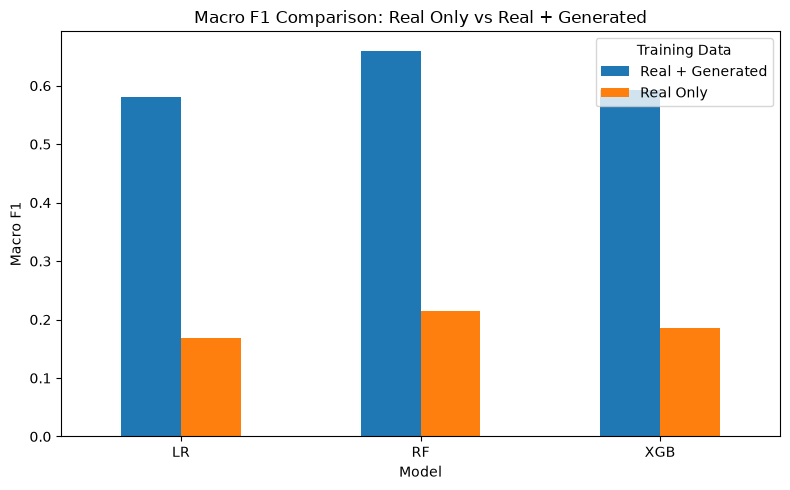

In [160]:
plot_data = experiment_comparison.pivot(
    index="Model",
    columns="Experiment",
    values="F1"
)

plot_data.plot(kind="bar", figsize=(8, 5))

plt.title("Macro F1 Comparison: Real Only vs Real + Generated")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=0)
plt.legend(title="Training Data")
plt.tight_layout()
plt.show()

## Dummy Classifier Baseline

After training the machine learning models, we used a **Dummy Classifier** as a simple baseline for comparison.

The Dummy Classifier uses the `most_frequent` strategy, which means it always predicts the disease that appears most often in the training data. It does not learn relationships between the symptoms and the disease.

We tested it on the same real test set and calculated the same metrics: **Accuracy, Precision, Recall, and Macro F1**.

This provides a simple reference point for the trained models. Comparing their results with the Dummy Classifier helps us check whether the machine learning models are learning useful patterns from the features rather than simply predicting the most common disease.


In [161]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_real_train, y_real_train)
y_dummy_pred = dummy.predict(X_real_test)

dummy_results = {
    "Model": "Dummy",
    "Accuracy": accuracy_score(y_real_test, y_dummy_pred),
    "Precision": precision_score(y_real_test,y_dummy_pred,average="macro",zero_division=0),
    "Recall": recall_score(y_real_test,y_dummy_pred,average="macro",zero_division=0),
    "F1": f1_score(y_real_test,y_dummy_pred,average="macro",zero_division=0)
}

print(dummy_results)

{'Model': 'Dummy', 'Accuracy': 0.0594059405940594, 'Precision': 0.0012639561828523278, 'Recall': 0.02127659574468085, 'F1': 0.002386160270431497}


The Dummy Classifier achieved 5.9% accuracy and a very low Macro F1-score of 0.002.

This is expected because the Dummy Classifier does not learn any relationship between the features and the diseases. It simply predicts the most frequent disease for every record.

Compared with the real models, which achieved higher results, this shows that the models are learning more useful patterns from the data rather than only predicting the most common disease.

We will use the Dummy Classifier as a simple baseline to compare with the other models.


In [162]:
dummy_df = pd.DataFrame([dummy_results])
real_only_with_dummy = pd.concat([dummy_df, results_df],ignore_index=True)

print(real_only_with_dummy)

   Model  Accuracy  Precision    Recall        F1 Experiment
0  Dummy  0.059406   0.001264  0.021277  0.002386        NaN
1     LR  0.306931   0.172163  0.207447  0.169237  Real Only
2     RF  0.346535   0.212513  0.251773  0.214235  Real Only
3    XGB  0.267327   0.188045  0.230496  0.185191  Real Only


The Dummy Classifier provides a simple baseline, while LR, RF, and XGB are the actual machine learning models. This comparison helps us see how much better the models perform compared with simply predicting the most frequent disease.
